In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

** <font size='6' color='red'>ch04. RNN(Recurrent Neural Network, 순환신경망)</font> **

# 1. 문맥을 이용하여 모델만들기

In [24]:
text = '''경마장에 있는 말이 뛰고 있다. 
그의 말이 법이다. 
가는 말이 고와야 오는 말이 곱다 '''
# text1 = '장마철이 오고 있다.'

In [25]:
from keras_preprocessing.text import Tokenizer
t = Tokenizer()
t.fit_on_texts([text])
encoded = t.texts_to_sequences([text])
print(encoded)
print(t.word_index)

[[2, 3, 1, 4, 5, 6, 1, 7, 8, 1, 9, 10, 1, 11]]
{'말이': 1, '경마장에': 2, '있는': 3, '뛰고': 4, '있다': 5, '그의': 6, '법이다': 7, '가는': 8, '고와야': 9, '오는': 10, '곱다': 11}


In [26]:
# 문자열 리스크를 인덱스 시퀀스로 변환
print(t.texts_to_sequences(['경마장에 말이 있다','말이 뛴다']))
print(t.texts_to_sequences(['가는 말이 곱다'])[0])

[[2, 1, 5], [1]]
[8, 1, 11]


In [27]:
for key, value in t.word_index.items():
    print(key, value)

말이 1
경마장에 2
있는 3
뛰고 4
있다 5
그의 6
법이다 7
가는 8
고와야 9
오는 10
곱다 11


In [36]:
# 학습을 시키기 위해 ['경마장에 있는', '경마장에 있는 말이', ...]
sequences = []
for line in text.split('\n'):
    print('원문장 :', line)
    encoded = t.texts_to_sequences([line])[0]
    print(('ecoded된 문장 :', encoded))
    for i in range(0, len(encoded)-1): # i: 시작 index
        for j in range(i+2, len(encoded)+1): # j: 끝나는 index 바로 뒤
            sequences.append(encoded[i:j])
# print(sequences)            
print('sepuences와 해석 출력')
for sequence in sequences:
    for word_seq in sequence:
        for word, value in t.word_index.items():
            if word_seq == value:
                print('{}:{}'.format(word_seq,word), end='')
                break
    print()

원문장 : 경마장에 있는 말이 뛰고 있다. 
('ecoded된 문장 :', [2, 3, 1, 4, 5])
원문장 : 그의 말이 법이다. 
('ecoded된 문장 :', [6, 1, 7])
원문장 : 가는 말이 고와야 오는 말이 곱다 
('ecoded된 문장 :', [8, 1, 9, 10, 1, 11])
sepuences와 해석 출력
2:경마장에3:있는
2:경마장에3:있는1:말이
2:경마장에3:있는1:말이4:뛰고
2:경마장에3:있는1:말이4:뛰고5:있다
3:있는1:말이
3:있는1:말이4:뛰고
3:있는1:말이4:뛰고5:있다
1:말이4:뛰고
1:말이4:뛰고5:있다
4:뛰고5:있다
6:그의1:말이
6:그의1:말이7:법이다
1:말이7:법이다
8:가는1:말이
8:가는1:말이9:고와야
8:가는1:말이9:고와야10:오는
8:가는1:말이9:고와야10:오는1:말이
8:가는1:말이9:고와야10:오는1:말이11:곱다
1:말이9:고와야
1:말이9:고와야10:오는
1:말이9:고와야10:오는1:말이
1:말이9:고와야10:오는1:말이11:곱다
9:고와야10:오는
9:고와야10:오는1:말이
9:고와야10:오는1:말이11:곱다
10:오는1:말이
10:오는1:말이11:곱다
1:말이11:곱다


In [41]:
print([len(sequence) for sequence in sequences])
my_len = max(len(sequence) for sequence in sequences)
my_len

[2, 3, 4, 5, 2, 3, 4, 2, 3, 2, 2, 3, 2, 2, 3, 4, 5, 6, 2, 3, 4, 5, 2, 3, 4, 2, 3, 2]


6

In [43]:
# sequences를 훈련 가능하도록 모두 6개로 조정
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences = pad_sequences(sequences=sequences,
                                maxlen = my_len,
                                padding='pre') # or 'post'
# padded_sequences
padded_sequences.shape, type(padded_sequences)

((28, 6), numpy.ndarray)

In [45]:
# 독립변수(X)와 타겟변수(y)로 분리
X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]

array([ 3,  1,  4,  5,  1,  4,  5,  4,  5,  5,  1,  7,  7,  1,  9, 10,  1,
       11,  9, 10,  1, 11, 10,  1, 11,  1, 11, 11])

In [47]:
# X를 임베딩 작업할 때 필요한 bit 수 (단어수+1)
input_dim = len(t.word_index)+1
input_dim

12

In [50]:
# y의 원핫인코딩
from tensorflow.keras.utils import to_categorical
Y = to_categorical(y, input_dim)
X.shape, Y.shape, input_dim

((28, 5), (28, 12), 12)

In [52]:
# 2. 모델 생성하기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding # Xi의 원핫인코딩한 희소행렬 변환, 
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

model = Sequential()
model.add(Embedding(input_dim=input_dim, # 12개로 원핫인코딩
                    output_dim=10, # 임베딩 출력의 갯수
                    input_length=X.shape[1], # 입력단어(X)의 수
                   ))
model.add(SimpleRNN(units=32))
model.add(Dense(12, activation='softmax'))
print(model.summary())
# 3. 모델 학습 과정 설정
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# 4. 모델 학습시키기
hist = model.fit(X,Y, epochs=300, verbose=2)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 5, 10)             120       
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 32)                1376      
                                                                 
 dense_1 (Dense)             (None, 12)                396       
                                                                 
Total params: 1,892
Trainable params: 1,892
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/300
1/1 - 1s - loss: 2.4912 - accuracy: 0.0714 - 1s/epoch - 1s/step
Epoch 2/300
1/1 - 0s - loss: 2.4814 - accuracy: 0.1071 - 5ms/epoch - 5ms/step
Epoch 3/300
1/1 - 0s - loss: 2.4716 - accuracy: 0.1071 - 6ms/epoch - 6ms/step
Epoch 4/300
1/1 - 0s - loss: 2.4616 - accuracy: 0.2143 - 1ms/epoch - 1ms/step
E

Epoch 95/300
1/1 - 0s - loss: 1.3190 - accuracy: 0.6071 - 5ms/epoch - 5ms/step
Epoch 96/300
1/1 - 0s - loss: 1.3067 - accuracy: 0.6071 - 1ms/epoch - 1ms/step
Epoch 97/300
1/1 - 0s - loss: 1.2945 - accuracy: 0.6071 - 4ms/epoch - 4ms/step
Epoch 98/300
1/1 - 0s - loss: 1.2824 - accuracy: 0.6071 - 5ms/epoch - 5ms/step
Epoch 99/300
1/1 - 0s - loss: 1.2703 - accuracy: 0.6429 - 7ms/epoch - 7ms/step
Epoch 100/300
1/1 - 0s - loss: 1.2583 - accuracy: 0.6429 - 3ms/epoch - 3ms/step
Epoch 101/300
1/1 - 0s - loss: 1.2464 - accuracy: 0.6429 - 5ms/epoch - 5ms/step
Epoch 102/300
1/1 - 0s - loss: 1.2345 - accuracy: 0.6429 - 3ms/epoch - 3ms/step
Epoch 103/300
1/1 - 0s - loss: 1.2228 - accuracy: 0.6429 - 5ms/epoch - 5ms/step
Epoch 104/300
1/1 - 0s - loss: 1.2112 - accuracy: 0.6429 - 5ms/epoch - 5ms/step
Epoch 105/300
1/1 - 0s - loss: 1.1997 - accuracy: 0.6429 - 4ms/epoch - 4ms/step
Epoch 106/300
1/1 - 0s - loss: 1.1883 - accuracy: 0.6429 - 5ms/epoch - 5ms/step
Epoch 107/300
1/1 - 0s - loss: 1.1770 - accur

Epoch 198/300
1/1 - 0s - loss: 0.5326 - accuracy: 0.8571 - 5ms/epoch - 5ms/step
Epoch 199/300
1/1 - 0s - loss: 0.5285 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 200/300
1/1 - 0s - loss: 0.5244 - accuracy: 0.8929 - 0s/epoch - 0s/step
Epoch 201/300
1/1 - 0s - loss: 0.5204 - accuracy: 0.8929 - 5ms/epoch - 5ms/step
Epoch 202/300
1/1 - 0s - loss: 0.5164 - accuracy: 0.8929 - 5ms/epoch - 5ms/step
Epoch 203/300
1/1 - 0s - loss: 0.5124 - accuracy: 0.8929 - 3ms/epoch - 3ms/step
Epoch 204/300
1/1 - 0s - loss: 0.5085 - accuracy: 0.8929 - 8ms/epoch - 8ms/step
Epoch 205/300
1/1 - 0s - loss: 0.5047 - accuracy: 0.8929 - 0s/epoch - 0s/step
Epoch 206/300
1/1 - 0s - loss: 0.5008 - accuracy: 0.8929 - 9ms/epoch - 9ms/step
Epoch 207/300
1/1 - 0s - loss: 0.4971 - accuracy: 0.8929 - 3ms/epoch - 3ms/step
Epoch 208/300
1/1 - 0s - loss: 0.4934 - accuracy: 0.8929 - 3ms/epoch - 3ms/step
Epoch 209/300
1/1 - 0s - loss: 0.4897 - accuracy: 0.8929 - 9ms/epoch - 9ms/step
Epoch 210/300
1/1 - 0s - loss: 0.4860 - accura

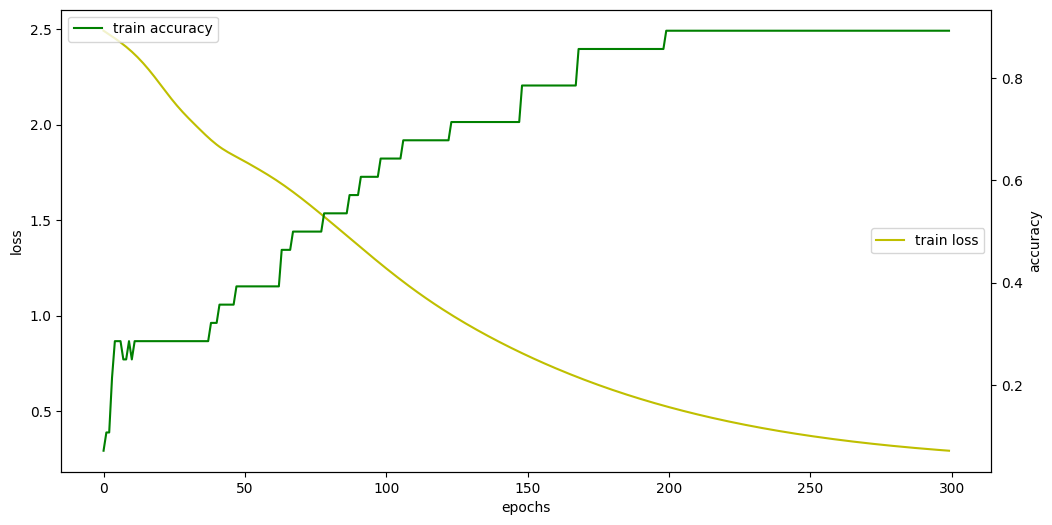

In [53]:
# 5. 모델 학습과정 시각화
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
# loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
# acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [65]:
# 모델 사용하기 (경마장에 있는 말이 -> 뛰고)
input_word = input('입력단어 :')
encoded = t.texts_to_sequences([input_word])[0]
# encoded = t.texts_to_sequences(['경마장에 있는 말이'])[0]
input_data = pad_sequences([encoded], maxlen=my_len-1, padding='pre')
print('입력데이터 :',input_data)
result = model.predict(input_data).argmax()
word = t.index_word.get(result,'??')
print('예측된 단어 :', word)

입력단어 :말이
입력데이터 : [[0 0 0 0 1]]
1/1 [==============================] - 0s 18ms/step
예측된 단어 : 고와야


In [60]:
t.texts_to_sequences(['없는 단어'])

[[]]

# 2. 다음 문맥 예측해 보기

In [74]:
# '경마장에' -> '경마장에 있는' -> '경마장에 있는 말이' 처럼 처음 이후에 올 단어 3개 예측 -> '경마장에 있는 말이 뛰고'
def sentence_generation(model, t, current_word, n):
    print('입력된 단어 :', current_word)
    for i in range(1, n+1):
        encoded = t.texts_to_sequences([current_word])[0]
        input_data = pad_sequences([encoded], maxlen=my_len-1, padding='pre')
        result = model.predict(input_data, verbose=0).argmax()
        word = t.index_word[result]
        current_word = current_word + ' ' + word
        print('{}번째 생성 문맥 {} ({}{}) :'.format(i,current_word,encoded,result))
    return current_word
sentence_generation(model, t, '경마장에', 3)

입력된 단어 : 경마장에
1번째 생성 문맥 경마장에 있는 ([2]3) :
2번째 생성 문맥 경마장에 있는 말이 ([2, 3]1) :
3번째 생성 문맥 경마장에 있는 말이 뛰고 ([2, 3, 1]4) :


'경마장에 있는 말이 뛰고'

In [76]:
sentence_generation(model, t, '말이', 3)

입력된 단어 : 말이
1번째 생성 문맥 말이 고와야 ([1]9) :
2번째 생성 문맥 말이 고와야 오는 ([1, 9]10) :
3번째 생성 문맥 말이 고와야 오는 말이 ([1, 9, 10]1) :


'말이 고와야 오는 말이'